In [1]:
# 第2章｜大盤歷史圖表分析：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


# 大盤歷史圖表分析

**對應影片**：第 2 章 單元 1「大盤歷史圖表分析」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 讀自己爬的大盤 1 分 K：`data.get('發行量加權股價指數')` | 讀 FinLab 的加權指數日資料：`data.get('taiex_total_index:收盤指數')` |
| 用 1 分 K 整理成日資料，再算均線、乖離率 | 直接用日資料計算，概念與圖表相同 |
| 未來報酬用大盤點數計算 | 未來報酬改用「買進 0050、持有 N 天」計算，因為大盤指數本身買不到 |

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import finlab.ml.label as label

plt.style.use('ggplot')

## 1. 讀取加權指數

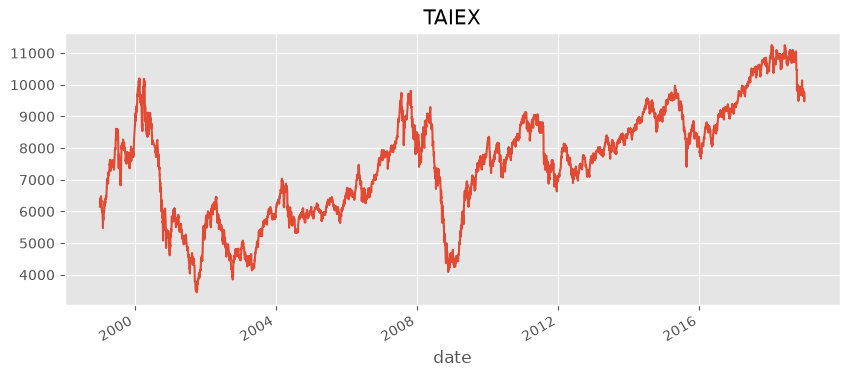

In [3]:
taiex = data.get('taiex_total_index:收盤指數')['TAIEX']
taiex.plot(figsize=(10, 4), title='TAIEX');

每日漲跌幅的分布：大部分日子漲跌在 ±1% 內，但偶爾會有很大的波動（分布的「肥尾」）。

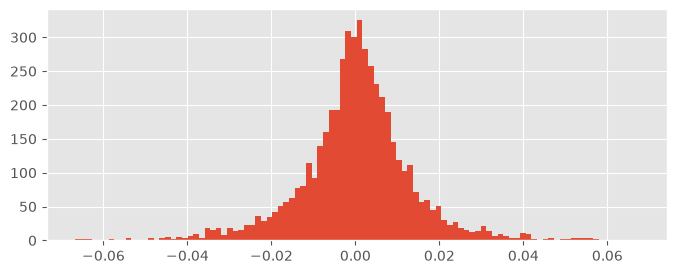

In [4]:
daily_return = taiex.pct_change()
daily_return.hist(bins=100, figsize=(8, 3));

## 2. DataFrame 小教室：groupby

`groupby` 把資料依照某個「分組依據」分堆，再對每一堆做計算。

In [5]:
s = pd.Series([1, 2, 3, 4, 5, 6])
s.groupby([0, 1, 0, 1, 0, 1]).sum()

0     9
1    12
dtype: int64

## 3. 每月漲跌

依照（年, 月）分組，取每個月第一天與最後一天的指數，算出當月漲跌幅，再排成「年 × 月」的表。

In [6]:
month_first = taiex.groupby([taiex.index.year, taiex.index.month]).first()
month_last = taiex.groupby([taiex.index.year, taiex.index.month]).last()

monthly_return = (month_last / month_first - 1).rename_axis(['year', 'month']).unstack('month')
monthly_return.tail()

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2014,-0.017413,0.045387,0.028749,-0.009209,0.023523,0.029551,-0.013352,0.018320,-0.057409,-0.001724,0.020244,0.020789
2015,0.009467,0.025046,-0.001554,0.032857,-0.014624,-0.031444,-0.075720,-0.040999,0.020415,0.031144,-0.034146,-0.014798
2016,0.003814,0.031164,0.030538,-0.032301,0.029113,0.008075,0.028172,-0.001306,0.018409,0.006056,-0.003450,-0.001083
2017,0.018880,0.034097,0.014134,-0.007787,0.010004,0.030498,0.001396,0.014227,-0.019904,0.031403,-0.022757,0.004008
2018,0.036698,-0.030894,0.012396,-0.021159,0.024122,-0.010245,0.025939,-0.003081,0.003842,-0.113074,0.004397,-0.040488


### 每月漲跌色溫圖

紅色是上漲、綠色是下跌（台股習慣）。可以觀察有沒有特別容易漲或跌的月份。

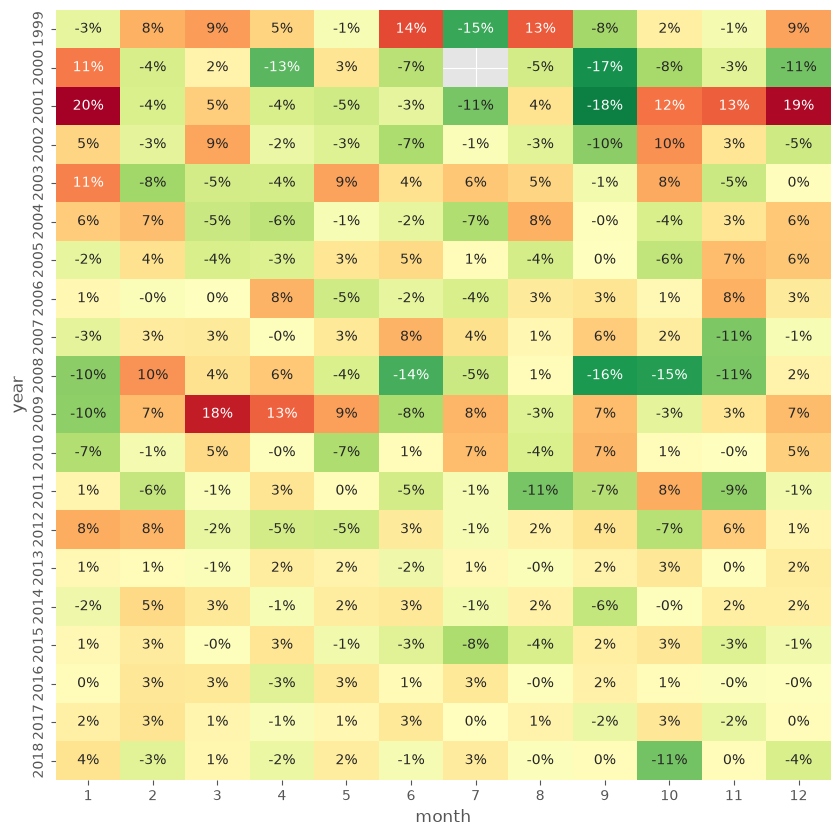

In [7]:
plt.figure(figsize=(10, 10))
sns.heatmap(monthly_return, cmap='RdYlGn_r', center=0, annot=True, fmt='.0%', cbar=False);

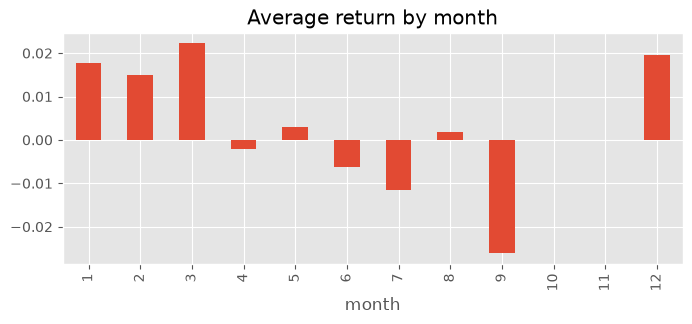

In [8]:
monthly_return.mean().plot.bar(figsize=(8, 3), title='Average return by month');

## 4. 均線與乖離率

- **60 日均線**：過去 60 個交易日的平均指數，大約是一季。
- **乖離率**：指數 ÷ 均線。大於 1 代表指數在均線之上。

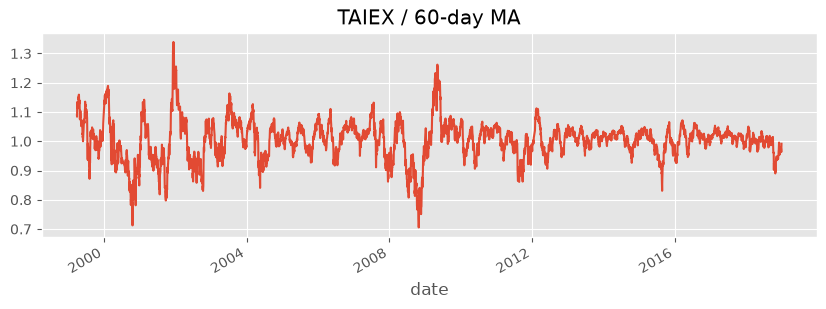

In [9]:
MA_WINDOW = 60
HOLDING_DAYS = 60

bias = taiex / taiex.rolling(MA_WINDOW).mean()
bias.plot(figsize=(10, 3), title=f'TAIEX / {MA_WINDOW}-day MA');

### 乖離率和之後的報酬有關係嗎？

對每一天，計算「隔天買進 0050、持有 60 個交易日」的報酬。
`finlab.ml.label.return_percentage` 會幫我們算好每個日期之後的報酬，日期對齊的細節都處理好了。

In [10]:
def forward_return(dates: pd.DatetimeIndex, period: int, stock_id: str = '0050') -> pd.Series:
    """每個日期「隔天買進、持有 period 個交易日」的報酬率。"""
    index = pd.MultiIndex.from_product([dates, [stock_id]], names=['datetime', 'instrument'])
    return label.return_percentage(index, period=period).droplevel('instrument')


analysis = pd.DataFrame({
    'bias': bias,
    'future_return': forward_return(bias.index, HOLDING_DAYS),
}).dropna()
analysis['year'] = analysis.index.year
analysis.tail()

,bias,future_return,year
2018-09-28,1.010737,-0.144820,2018
2018-10-01,1.014223,-0.142940,2018
2018-10-02,1.001789,-0.144270,2018
2018-10-03,0.996516,-0.116019,2018
2018-10-04,0.983150,-0.095267,2018


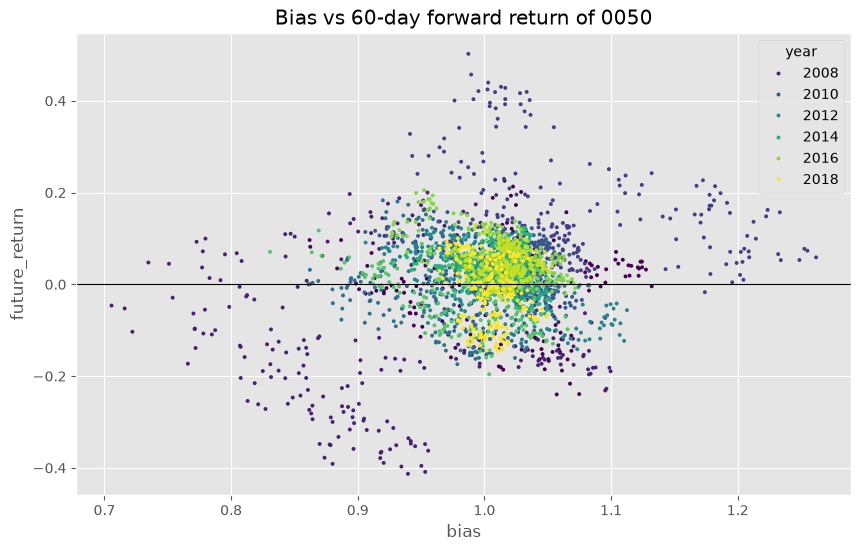

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=analysis, x='bias', y='future_return', hue='year', palette='viridis', s=8, linewidth=0)
plt.axhline(0, color='black', linewidth=0.8)
plt.title(f'Bias vs {HOLDING_DAYS}-day forward return of 0050');

把乖離率分成 5 組，看每組之後的平均報酬與上漲機率：

In [12]:
N_BINS = 5

analysis['bias_group'] = pd.qcut(analysis['bias'], N_BINS)
analysis.groupby('bias_group', observed=True)['future_return'].agg(
    average_return='mean',
    win_rate=lambda r: (r > 0).mean(),
    days='size',
)

,average_return,win_rate,days
bias_group,,,
"(0.705, 0.972]",-0.006744,0.572183,568
"(0.972, 1.003]",0.021927,0.666667,567
"(1.003, 1.02]",0.032392,0.711268,568
"(1.02, 1.038]",0.030620,0.731922,567
"(1.038, 1.262]",0.009967,0.573944,568


## 5. 最新的乖離率

In [13]:
bias.tail()

date
2018-12-24    0.974895
2018-12-25    0.965773
2018-12-26    0.963151
2018-12-27    0.981460
2018-12-28    0.991527
Name: TAIEX, dtype: float64

散佈圖的點很分散：同樣的乖離率，之後可能大漲也可能大跌。分組平均能看出一些傾向，但單靠乖離率做預測並不可靠。

下一個單元我們把「站上均線就買」寫成策略，比較哪一條均線最有用。